# EDA for iris dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

## Univariate Analysis

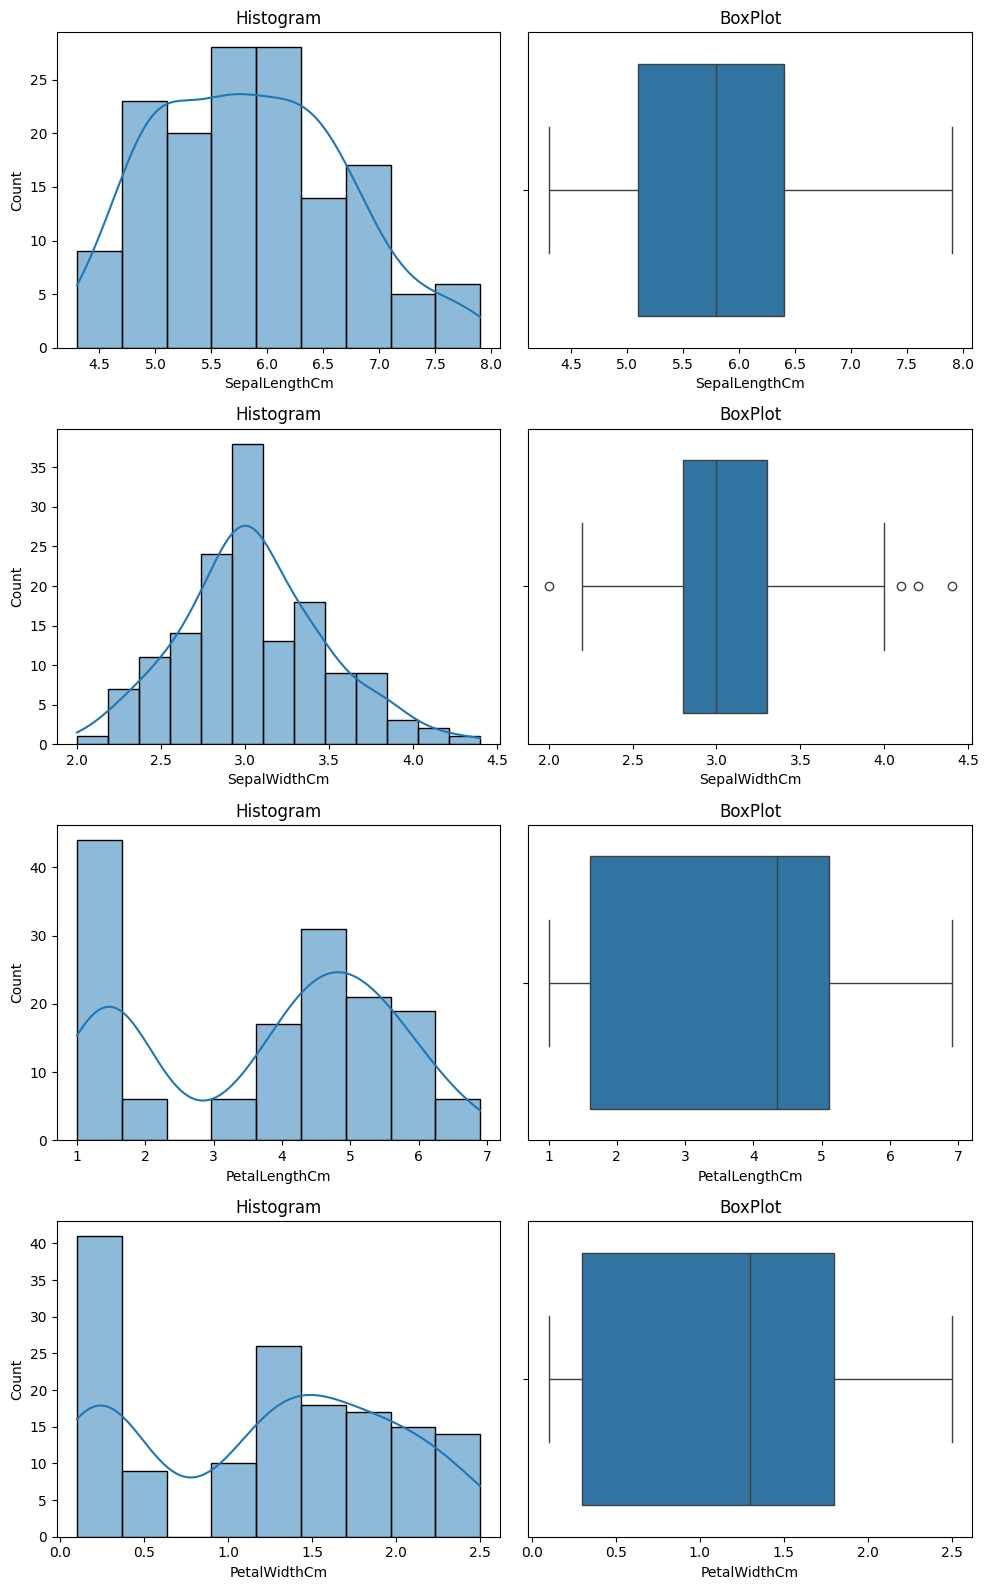

In [26]:
num_cols = df.select_dtypes("number").columns[1:]
n = len(num_cols)

fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))

for index, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[index, 0])
    axes[index, 0].set_title(f"Histogram")

    sns.boxplot(x=df[col], ax=axes[index, 1])
    axes[index, 1].set_title(f"BoxPlot")

plt.tight_layout()
plt.show()

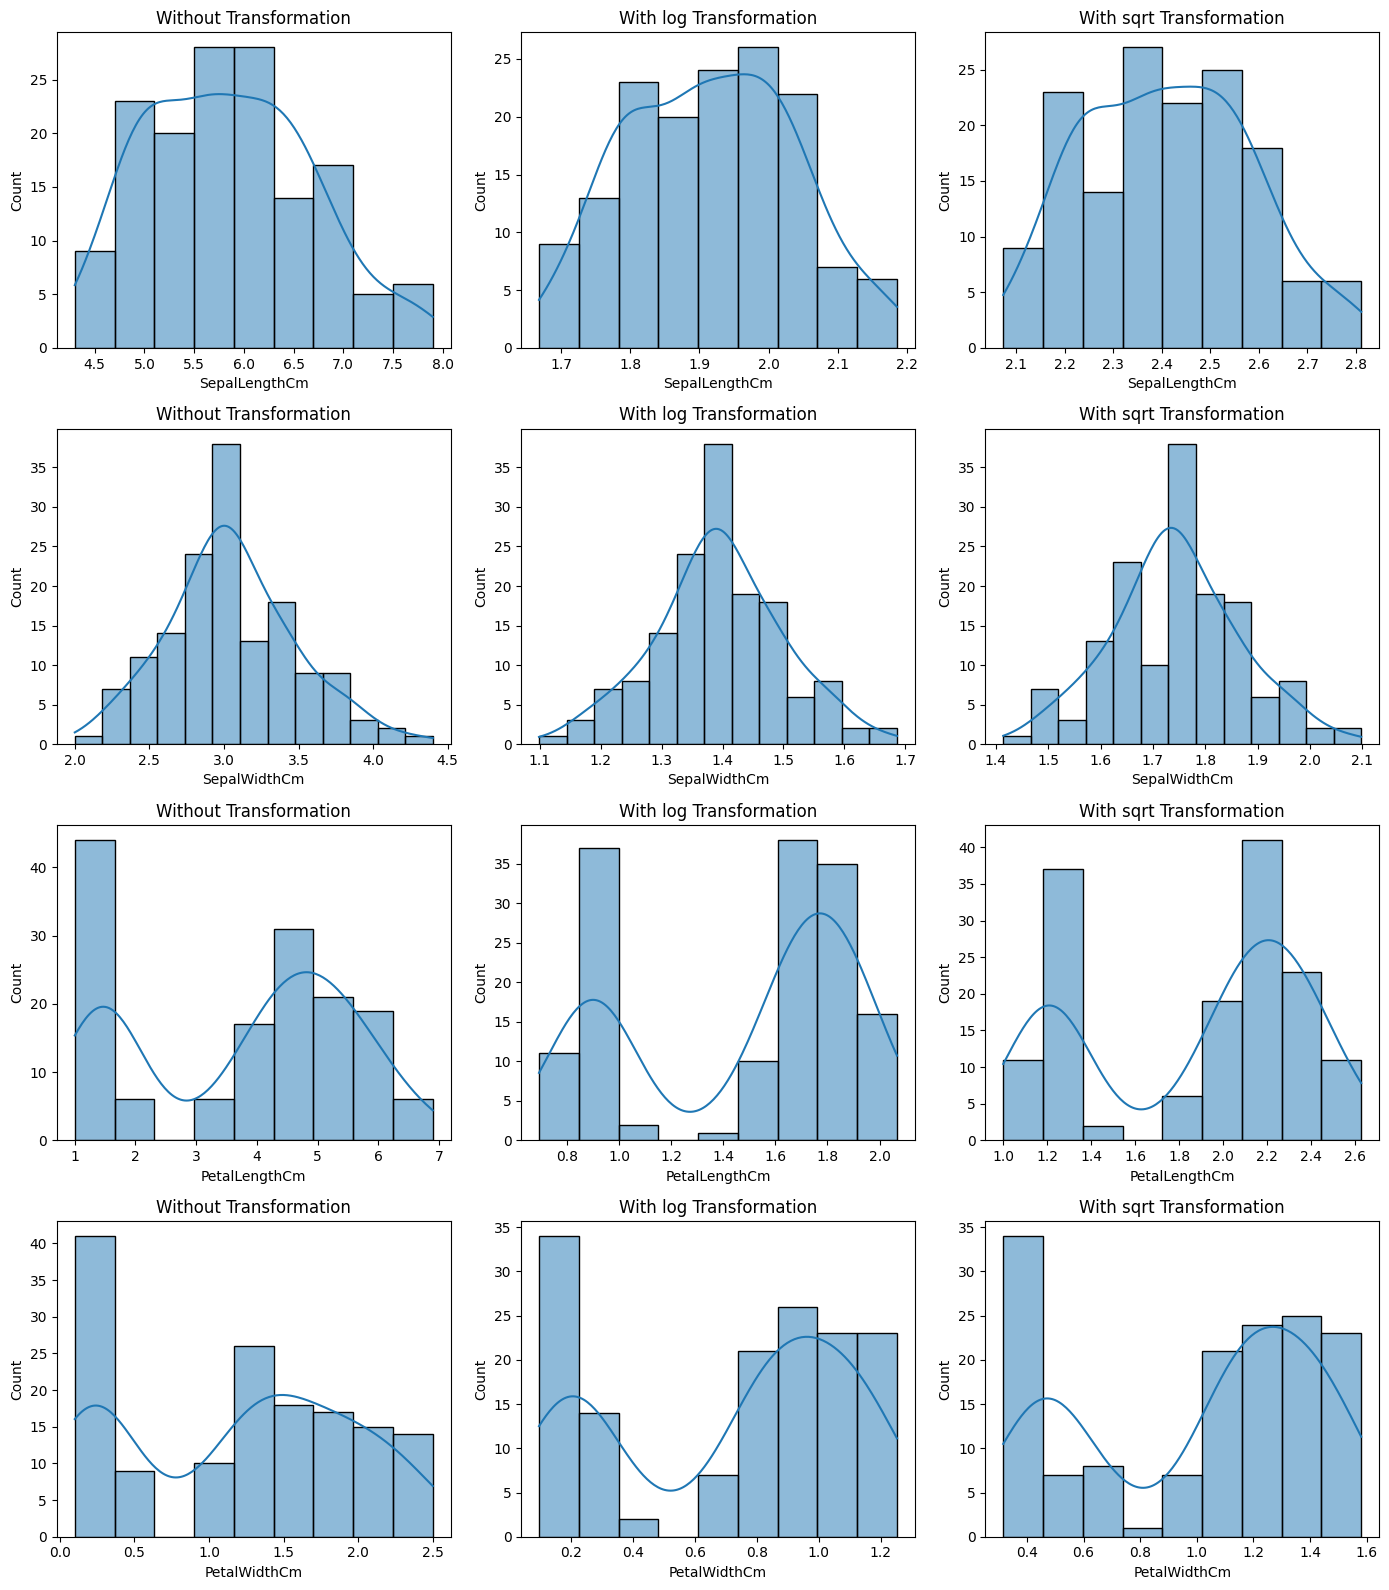

In [21]:
num_cols = df.select_dtypes("number").columns[1:]
n = len(num_cols)

fig, axes = plt.subplots(n, 3, figsize=(14, 4*n))

for index, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[index, 0])
    axes[index, 0].set_title(f"Without Transformation")

    sns.histplot(np.log1p(df[col]), kde=True, ax=axes[index, 1])
    axes[index, 1].set_title(f"With log Transformation")

    sns.histplot(np.sqrt(df[col]), kde=True, ax=axes[index, 2])
    axes[index, 2].set_title(f"With sqrt Transformation")

plt.tight_layout()
plt.show()

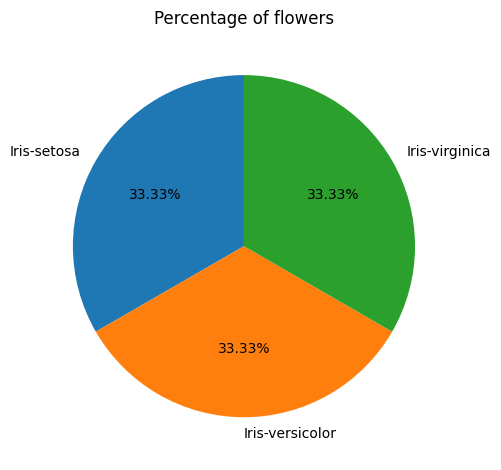

In [35]:
flower_types = df['Species'].value_counts().index
flower_counts = df['Species'].value_counts().values

plt.pie(flower_counts, labels=flower_types, autopct="%.2f%%", startangle=90)
plt.title("Percentage of flowers")
plt.tight_layout()
plt.show()

## Bivariate Analysis

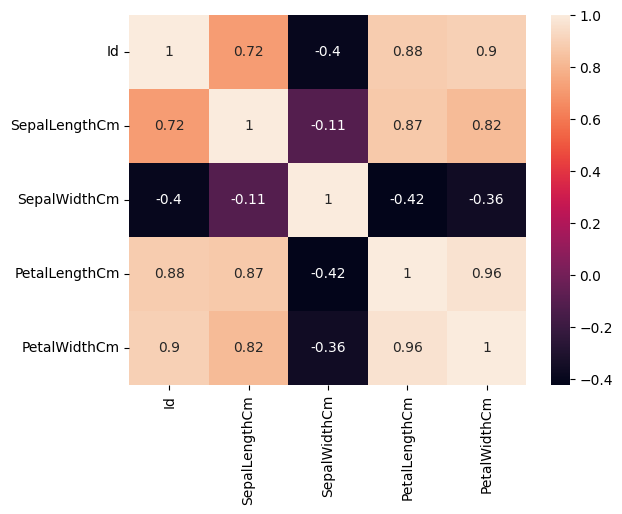

In [42]:
corr = df.select_dtypes("number").corr()

sns.heatmap(corr, annot=True)
plt.show()

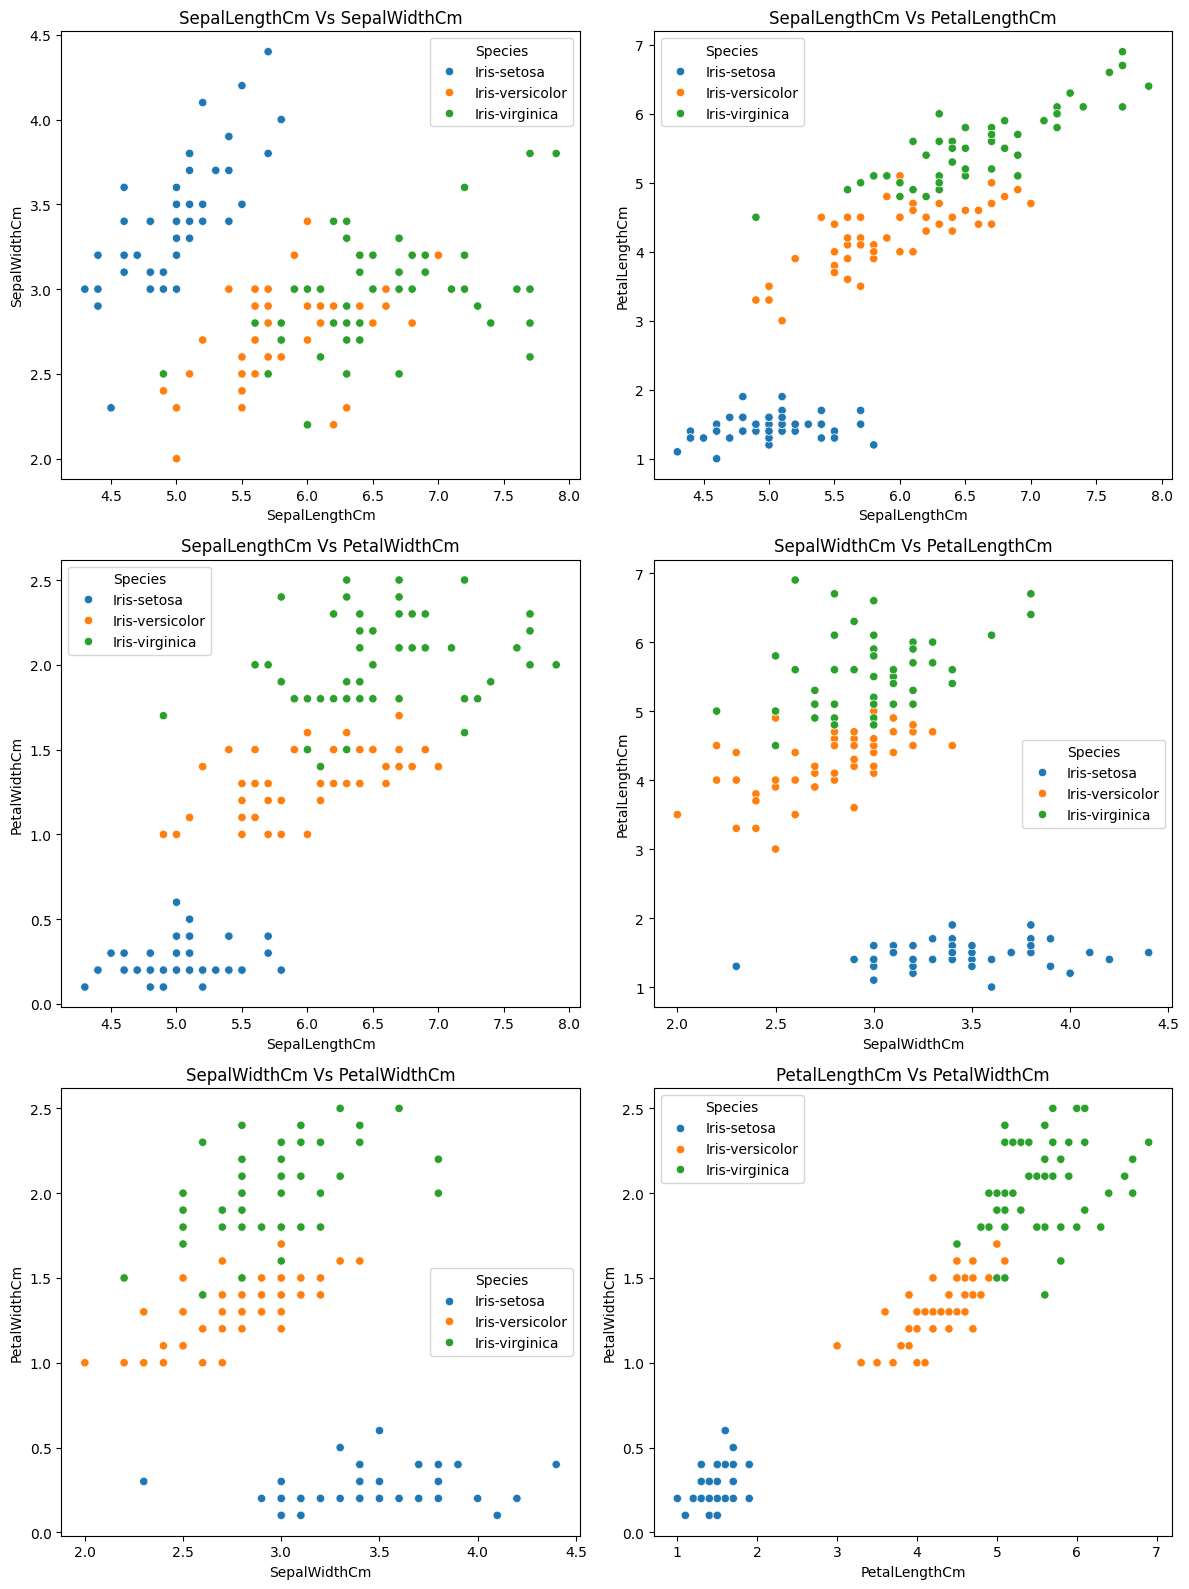

In [52]:
pairs = [
    ("SepalLengthCm", "SepalWidthCm"),
    ("SepalLengthCm", "PetalLengthCm"),
    ("SepalLengthCm", "PetalWidthCm"),
    ("SepalWidthCm", "PetalLengthCm"),
    ("SepalWidthCm", "PetalWidthCm"),
    ("PetalLengthCm", "PetalWidthCm")
]

fig, axes = plt.subplots(int(len(pairs) / 2), 2, figsize=(12, 4*n))

for ax, (x, y) in zip(axes.flat, pairs):
    sns.scatterplot(data=df, x=x, y=y, ax=ax, hue=df['Species'])
    ax.set_title(f"{x} Vs {y}")

plt.tight_layout()
plt.show()

## Observations

## 1) Histograms

- Sepal length and sepal width exhibit approximately **near-normal (bell-shaped)** distributions with moderate spread.
- Petal length and petal width exhibit **multi-modal distributions**, where distinct peaks correspond to different species.
- The apparent “gap” in petal features is **not missing data**, but indicates **clear class separation**.

**Conclusion:**  
Petal features are significantly more discriminative than sepal features.

---

## 2) Transformations

- Log and square root transformations were applied to all features.
- Sepal features showed minimal change, as they are already close to normally distributed.
- Petal features remained multi-modal even after transformation.

**Conclusion:**  
Transformations are ineffective here because the issue is **multi-modality (class separation)**, not skewness.

---

## 3) Boxplots

- Sepal features show **little to no significant outliers**, indicating stable distributions.
- Petal features also show **no major outliers**.
- The position of the median is slightly shifted due to the **combined distribution of multiple species**, not due to missing values.

**Conclusion:**  
Boxplots reflect **mixture distributions across classes**, rather than any anomaly in the data.

---

## 4) Class Distribution

- All three species (Setosa, Versicolor, Virginica) are equally represented (33.33% each).

**Conclusion:**  
The dataset is **perfectly balanced**, with no class imbalance.

---

## 5) Scatter Plots

- When plotting petal features:
  - Clear clustering is observed.
  - **Setosa is completely separable** from the other species.
  - Some overlap exists between **Versicolor and Virginica**.
- Sepal feature plots show weaker separation.

**Conclusion:**  
Petal features provide **strong class separation**, especially for identifying Setosa.

---

## 6) Correlation Heatmap

- A strong positive correlation (~0.96) exists between:
  - Petal length and petal width

**Conclusion:**  
These features carry **similar information**, indicating potential redundancy, especially in linear models.

---

## Final Summary

- Sepal features → weak predictors  
- Petal features → strong predictors  
- Dataset → clean and balanced  
- Strong class separation exists (especially for Setosa)  
- Some feature redundancy is present  

**Overall Insight:**  
Petal-based features are the most important for classification in this dataset.